In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
rng = np.random.default_rng(seed=42)
m = 200 # number of instances
X = 2 * rng.random((m, 1)) # colume vecor
y = 4 + 3 * X + rng.standard_normal((m, 1)) # column vector

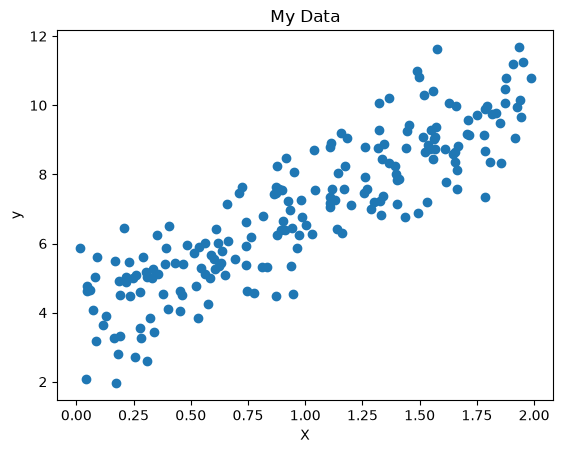

In [3]:
plt.scatter(X, y)  # Scatter plot of the data points
plt.xlabel('X')
plt.ylabel('y')
plt.title('My Data')
plt.show()

In [4]:
from sklearn.preprocessing import add_dummy_feature

In [5]:
X_b = add_dummy_feature(X)
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

In [6]:
theta_best

array([[3.69084138],
       [3.32960458]])

In [7]:
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)

In [8]:
y_predict = X_new_b @ theta_best
y_predict

array([[ 3.69084138],
       [10.35005055]])

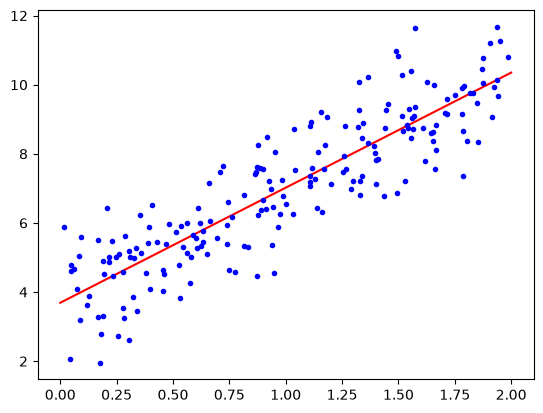

In [9]:
import matplotlib.pyplot as plt

plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.plot(X, y, "b.")
plt.show()

### Performing Linear Regression using Scikit-Learn 

In [10]:
from sklearn.linear_model import LinearRegression

In [11]:
lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([3.69084138]), array([[3.32960458]]))

In [12]:
lin_reg.predict(X_new)

array([[ 3.69084138],
       [10.35005055]])

In [13]:
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)

In [14]:
theta_best_svd

array([[3.69084138],
       [3.32960458]])

In [15]:
residuals

array([199.16171014])

In [16]:
rank

np.int32(2)

### Batch-Gradient-Descent

In [17]:
eta = 0.1 # learning rate
n_epochs = 1000
m = len(X_b) # number of instances

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2, 1)) # randomly initialized model parameters

for epoch in range(n_epochs):
    gradients = 2/ m* X_b.T @ (X_b @ theta - y)
    theta = theta  - eta * gradients

In [18]:
theta

array([[3.69084138],
       [3.32960458]])

### Stochastic Gradient Descent

In [19]:
n_epochs = 50
t0, t1 = 5, 50 # learning schedule hyperparameters

def learning_schedule(t):
    return t0 / (t + t1)

rng = np.random.default_rng(seed= 42)
theta = rng.standard_normal((2, 1)) # randomly initialized model parameter

for epoch in range(n_epochs):
    for iteration in range(m):
        random_index = rng.integers(m)
        xi = X_b[random_index : random_index + 1]
        yi = y[random_index : random_index + 1]
        gradients = 2 * xi.T @ (xi @ theta - yi)  # for SGD, do not divide by m

        eta = learning_schedule(epoch * m + iteration)
        theta = theta - eta * gradients

In [20]:
theta

array([[3.69826475],
       [3.30748311]])

In [21]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter=1000, tol=1e-5, penalty=None, eta0=0.01,
                       n_iter_no_change=100, random_state=42)
sgd_reg.fit(X, y.ravel())  # y.ravel() because fit() expects 1D targets

,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",None
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",1e-05
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_iter_no_change n_iter_no_change: int, default=5Number of iterations with no improvement to wait before stoppingfitting.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Integer values must be in the range `[1, max_iter)`... versionadded:: 0.20 Added 'n_iter_no_change' option",100
,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide <sgd_mathematical_formulation>`.",'squared_error'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0


In [22]:
sgd_reg.intercept_, sgd_reg.coef_

(array([3.68899733]), array([3.33054574]))

In [23]:
rng = np.random.default_rng(seed=42)
m = 200  # number of instances
X = 6 * rng.random((m, 1)) - 3
y = 0.5 * X ** 2 + X + 2 + rng.standard_normal((m, 1))

<function matplotlib.pyplot.show(close=None, block=None)>

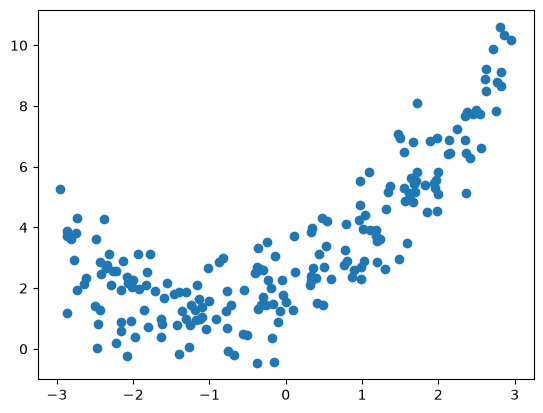

In [24]:
plt.scatter(X, y)
plt.show

**Clearly, a straight line will never fit this data properly. So let’s use Scikit-Learn’s PolynomialFeatures class to transform our training data, adding the square (second-degree polynomial) of each feature in the training set as a new feature (in this case there is just one feature):**

In [25]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias = False)

X_poly = poly_features.fit_transform(X)
X[0]

array([1.64373629])

In [26]:
X_poly[0]

array([1.64373629, 2.701869  ])

In [27]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([2.00540719]), array([[1.11022126, 0.50526985]]))

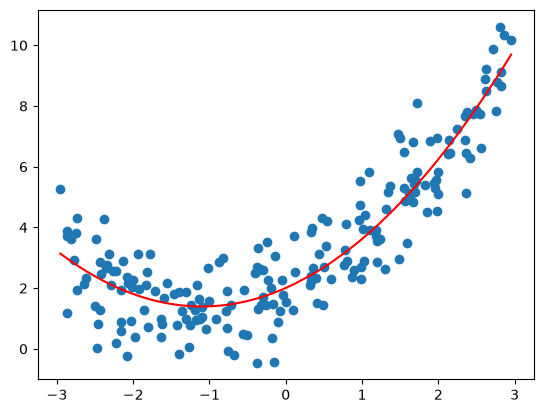

In [28]:
# Sort indices to get proper order
idx = np.argsort(X, axis=0).ravel()
X_sorted = X[idx]
y_sorted = y[idx]

plt.scatter(X, y)
plt.plot(X_sorted, lin_reg.predict(poly_features.transform(X_sorted)), 'r')
plt.show()

In [29]:
from sklearn.model_selection import learning_curve

In [30]:
train_sizes, train_scores, valid_scores = learning_curve(
    LinearRegression(),        # The model you're testing
    X, y,                      # Your data
    train_sizes=np.linspace(0.01, 1.0, 40),  # Try 40 different training set sizes
    cv=5,                      # 5-fold cross-validation
    scoring="neg_root_mean_squared_error")  # Measure error (negative because sklearn is weird)


train_errors = -train_scores.mean(axis=1)  # Average error across 5 folds, make positive
valid_errors = -valid_scores.mean(axis=1)  # Same for validation



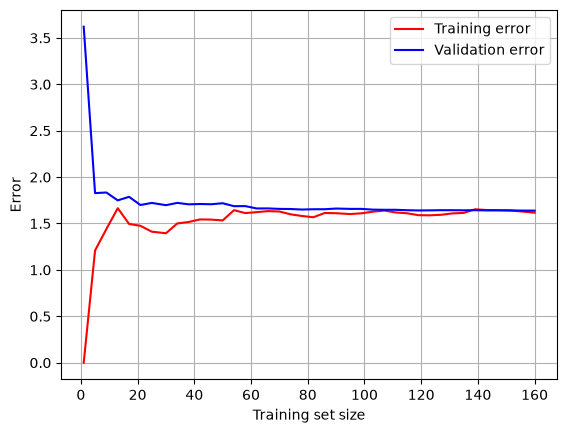

In [31]:
# Plot
plt.plot(train_sizes, train_errors, 'r-', label='Training error')
plt.plot(train_sizes, valid_errors, 'b-', label='Validation error')
plt.xlabel('Training set size')
plt.ylabel('Error')
plt.legend()
plt.grid(True)
plt.show()

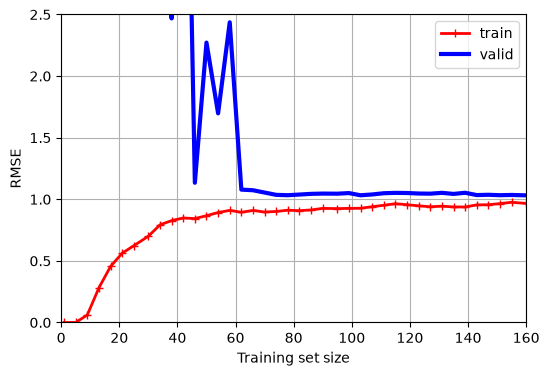

In [32]:
from sklearn.pipeline import make_pipeline

polynomial_regression = make_pipeline(
    PolynomialFeatures(degree=10, include_bias=False),
    LinearRegression())

train_sizes, train_scores, valid_scores = learning_curve(
    polynomial_regression, X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring="neg_root_mean_squared_error")

# Calculate errors from scores
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.figure(figsize=(6, 4))
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.legend(loc="upper right")
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.grid()
plt.axis([0, 160, 0, 2.5])

plt.show()

In [33]:
from sklearn.linear_model import Ridge

In [34]:
ridge_reg = Ridge(alpha=0.1, solver="cholesky")
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

array([5.06157854])

In [35]:
sgd_reg = SGDRegressor(penalty="l2", alpha=0.1 / m, tol=None, max_iter=1000, eta0=0.01, random_state=42)

In [36]:
sgd_reg.fit(X, y.ravel())
sgd_reg.predict([[1.5]])

array([5.06208065])

In [37]:
from sklearn.linear_model import Lasso

In [38]:
lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X, y)
lasso_reg.predict([[1.5]])

array([5.00803756])

In [41]:
from sklearn.linear_model import ElasticNet
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net.fit(X, y)
elastic_net.predict([[1.5]])

array([5.006944])